In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv(r"C:\Users\ADMIN\Desktop\ML\ott_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (33171, 23)


,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,...,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk,dataset_version
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,1,48,4,5,...,3,0,0,9,high,0,1,0.649,high,v1.0
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,2,55,5,4,...,3,3,1,5,medium,0,0,0.473,medium,v1.0
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,3,51,4,8,...,4,2,0,9,high,0,0,0.583,medium,v1.0
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,4,50,4,7,...,4,1,0,7,high,0,0,0.520,medium,v1.0
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,5,52,4,3,...,3,0,1,7,high,0,1,0.638,high,v1.0


In [3]:
print(df.info())
print("\nMissing Values:\n", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33171 entries, 0 to 33170
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   show_id               33171 non-null  int64  
 1   title                 33171 non-null  object 
 2   platform              33171 non-null  object 
 3   genre                 33171 non-null  object 
 4   release_year          33171 non-null  float64
 5   season_number         33171 non-null  int64  
 6   episode_number        33171 non-null  int64  
 7   episode_duration_min  33171 non-null  int64  
 8   pacing_score          33171 non-null  int64  
 9   hook_strength         33171 non-null  int64  
 10  dialogue_density      33171 non-null  object 
 11  visual_intensity      33171 non-null  int64  
 12  avg_watch_percentage  33171 non-null  int64  
 13  pause_count           33171 non-null  int64  
 14  rewind_count          33171 non-null  int64  
 15  skip_intro         

In [4]:
df.describe()

,show_id,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,visual_intensity,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,night_watch_safe,drop_off,drop_off_probability
count,33171.000000,33171.000000,33171.0,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000
mean,63698.539688,2000.739743,1.0,423.718881,37.660667,5.397908,5.525158,6.009436,56.805764,3.102921,2.003497,0.493262,6.196015,0.015887,0.144825,0.478433
std,65206.256887,15.750470,0.0,557.688460,22.899741,1.230418,1.730098,1.994370,12.577000,1.866938,1.548391,0.499962,1.322146,0.125042,0.351930,0.107382
min,36.000000,1952.000000,1.0,1.000000,1.000000,3.000000,3.000000,3.000000,13.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.120000
25%,15226.000000,1992.000000,1.0,27.000000,24.000000,4.000000,4.000000,4.000000,48.000000,2.000000,1.000000,0.000000,5.000000,0.000000,0.000000,0.400000
50%,35024.000000,2004.000000,1.0,178.000000,33.000000,5.000000,6.000000,6.000000,57.000000,3.000000,2.000000,0.000000,7.000000,0.000000,0.000000,0.471000
75%,80885.000000,2012.000000,1.0,611.000000,49.000000,6.000000,7.000000,8.000000,66.000000,4.000000,3.000000,1.000000,7.000000,0.000000,0.000000,0.553000
max,305062.000000,2025.000000,1.0,2650.000000,1225.000000,8.000000,10.000000,9.000000,100.000000,10.000000,8.000000,1.000000,9.000000,1.000000,1.000000,0.831000


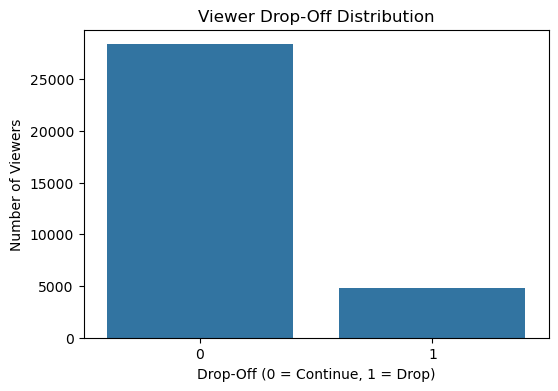

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="drop_off", data=df)
plt.title("Viewer Drop-Off Distribution")
plt.xlabel("Drop-Off (0 = Continue, 1 = Drop)")
plt.ylabel("Number of Viewers")
plt.show()

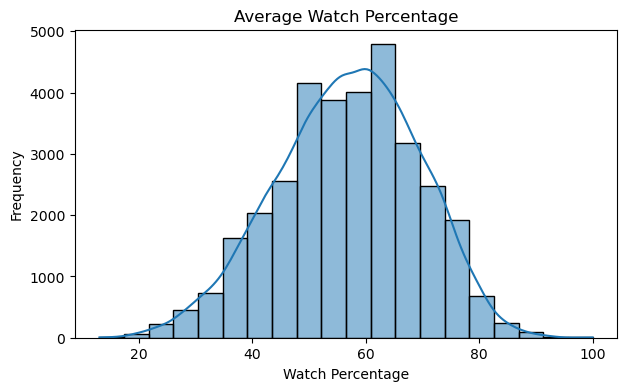

In [6]:
plt.figure(figsize=(7,4))
sns.histplot(
    df["avg_watch_percentage"],
    bins=20,
    kde=True
)
plt.title("Average Watch Percentage")
plt.xlabel("Watch Percentage")
plt.ylabel("Frequency")
plt.show()

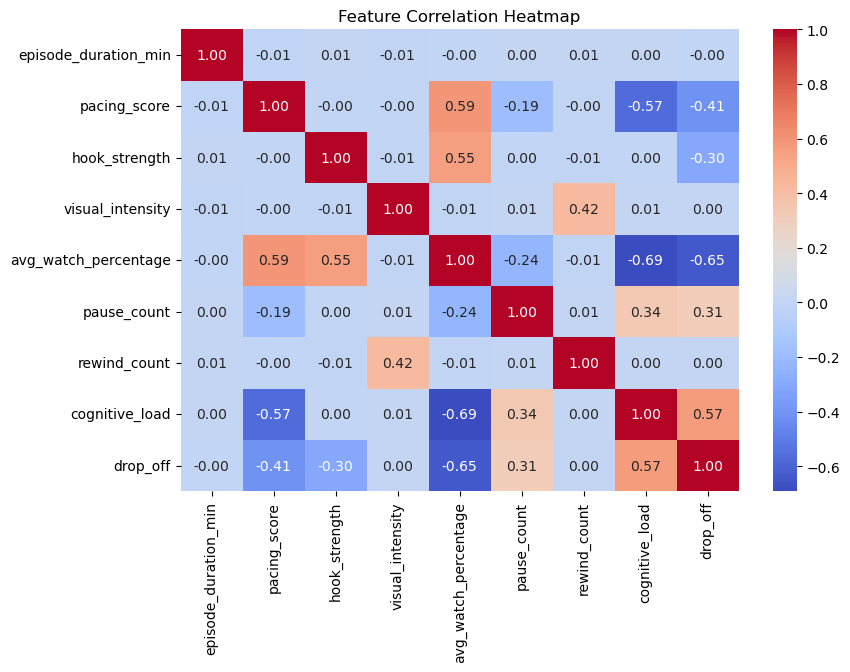

In [7]:
features = [
    "episode_duration_min",
    "pacing_score",
    "hook_strength",
    "visual_intensity",
    "avg_watch_percentage",
    "pause_count",
    "rewind_count",
    "cognitive_load"
]
plt.figure(figsize=(9,6))
sns.heatmap(
    df[features + ["drop_off"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Feature Correlation Heatmap")
plt.show()

In [8]:
X = df[features]
y = df["drop_off"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)
log_acc = accuracy_score(y_test, log_pred)
print("Logistic Regression Accuracy:",round(log_acc * 100, 2), "%")

Logistic Regression Accuracy: 99.83 %


In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:",round(rf_acc * 100, 2), "%")

Random Forest Accuracy: 99.55 %


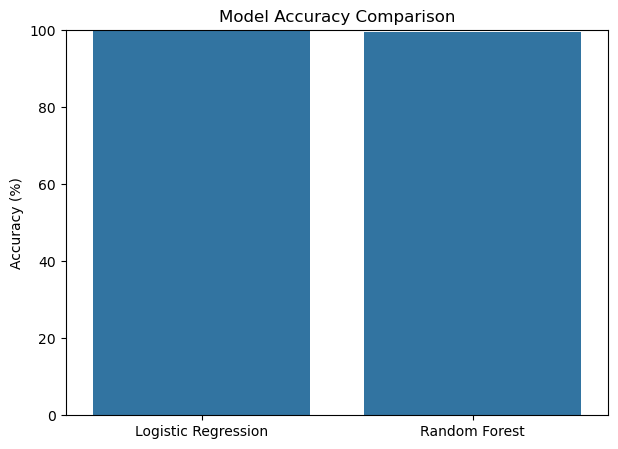

In [11]:
models = ["Logistic Regression", "Random Forest"]
accuracy = [log_acc * 100, rf_acc * 100]
plt.figure(figsize=(7,5))
sns.barplot(
    x=models,
    y=accuracy
)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(0,100)
plt.show()

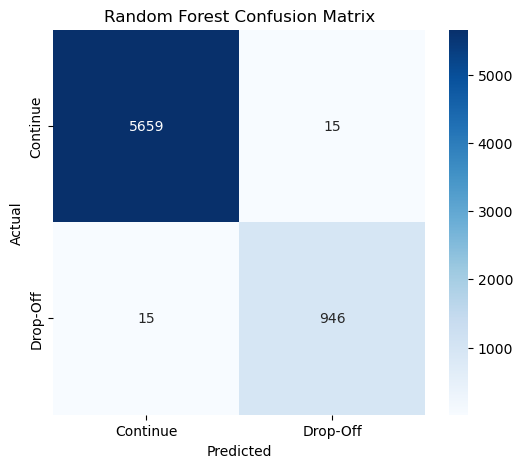

In [12]:
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Continue", "Drop-Off"],
    yticklabels=["Continue", "Drop-Off"]
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

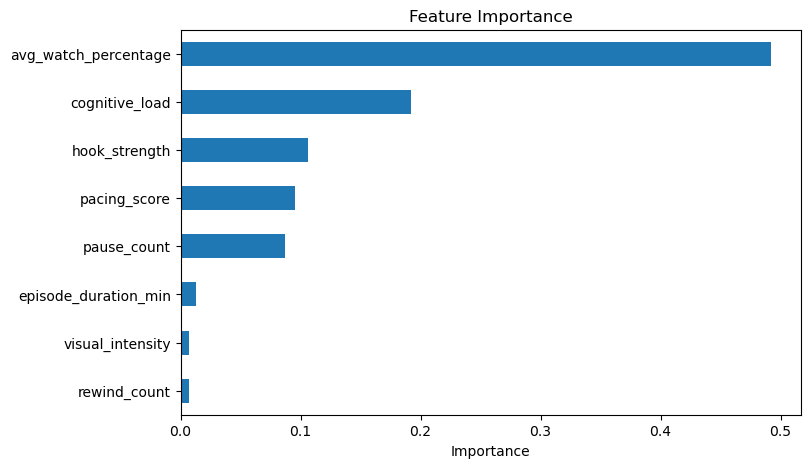

In [13]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)
plt.figure(figsize=(8,5))
importance.plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [14]:
new_episode = pd.DataFrame({
    "episode_duration_min": [45],
    "pacing_score": [8],
    "hook_strength": [9],
    "visual_intensity": [8],
    "avg_watch_percentage": [90],
    "pause_count": [1],
    "rewind_count": [1],
    "cognitive_load": [5]
})
prediction = rf_model.predict(new_episode)[0]
probability = rf_model.predict_proba(new_episode)[0]
if prediction == 0:
    print("Prediction: CONTINUE WATCHING")
else:
    print("Prediction: DROP-OFF")
print("Continue Probability:",
      round(probability[0]*100, 2), "%")
print("Drop-Off Probability:",
      round(probability[1]*100, 2), "%")

Prediction: CONTINUE WATCHING
Continue Probability: 100.0 %
Drop-Off Probability: 0.0 %


In [15]:
class_ratio = df["drop_off"].value_counts(normalize=True) * 100

print("Class Distribution:")
print(class_ratio.round(2))

Class Distribution:
drop_off
0    85.52
1    14.48
Name: proportion, dtype: float64


In [16]:
print("Random Forest Classification Report:\n")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Continue", "Drop-Off"]
    )
)

Random Forest Classification Report:

              precision    recall  f1-score   support

    Continue       1.00      1.00      1.00      5674
    Drop-Off       0.98      0.98      0.98       961

    accuracy                           1.00      6635
   macro avg       0.99      0.99      0.99      6635
weighted avg       1.00      1.00      1.00      6635



In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_test, rf_pred)
recall = recall_score(y_test, rf_pred)
f1 = f1_score(y_test, rf_pred)
print("Precision :", round(precision, 3))
print("Recall    :", round(recall, 3))
print("F1 Score  :", round(f1, 3))

Precision : 0.984
Recall    : 0.984
F1 Score  : 0.984


In [18]:
sample_data = X_test.head(10)
sample_predictions = rf_model.predict(sample_data)
result = sample_data.copy()
result["Actual"] = y_test.head(10).values
result["Predicted"] = sample_predictions
result

,episode_duration_min,pacing_score,hook_strength,visual_intensity,avg_watch_percentage,pause_count,rewind_count,cognitive_load,Actual,Predicted
16371,80,6,3,4,67,2,2,5,0,0
30507,54,6,7,7,77,3,0,5,0,0
26041,35,5,6,8,62,3,3,5,0,0
4209,48,7,4,8,59,8,1,7,0,0
5742,12,6,8,5,76,3,0,5,0,0
5087,12,6,4,3,53,4,0,5,0,0
17589,8,5,6,6,55,5,0,7,0,0
32940,36,4,6,8,34,3,3,9,1,1
31016,56,7,6,8,60,4,1,7,0,0
30541,50,6,4,9,61,1,4,5,0,0


In [19]:
result.to_csv(
    "ott_prediction_results.csv",
    index=False
)
print("Prediction results saved successfully!")

Prediction results saved successfully!
